# 04 — Anomaly Pattern Discovery

**Goal:** Discover recurring anomaly patterns and construct subsystem-aware feature groups.

**Story: Feature → Event → Failure → Dataset**

1. **Features:** Which of the 340 features activate during anomalous windows?
2. **Events:** Do these activations form recurring patterns (clusters)?
3. **Failures:** Which clusters are linked to actual failure events?
4. **Datasets:** Construct subsystem-aware feature groups from the verified clusters.

**Sections:**
1. Identify anomalous windows (z-score method on full period)
2. Feature activation profiles per anomalous window
3. Cluster recurring patterns (hierarchical clustering)
4. Link clusters to failure events
5. Map clusters to subsystems
6. Construct subsystem-aware feature groups (subdatasets)
7. Summary for expert verification

In [1]:
import sys, os, gc, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import f1_score
import joblib
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))
ROOT = os.path.abspath('..')
OUT_DIR = os.path.join(ROOT, 'outputs')

# Load supervised datasets + RF model
train_sup = pd.read_parquet(os.path.join(OUT_DIR, 'supervised', 'train.parquet'))
test_sup = pd.read_parquet(os.path.join(OUT_DIR, 'supervised', 'test.parquet'))
train_sup['window_end'] = pd.to_datetime(train_sup['window_end'])
test_sup['window_end'] = pd.to_datetime(test_sup['window_end'])

saved = joblib.load(os.path.join(OUT_DIR, 'supervised', 'rf_model.joblib'))
rf_model = saved['model']
RF_THR = saved['threshold']

feature_cols = [c for c in train_sup.columns if c not in {'timestamp', 'window_end', 'label'}]

# Combine train+test
train_sup['split'] = 'train'
test_sup['split'] = 'test'
all_sup = pd.concat([train_sup, test_sup], ignore_index=True).sort_values('window_end').reset_index(drop=True)
del train_sup, test_sup; gc.collect()

# Subsystem mapping
def get_subsystem(name):
    name_upper = name.upper()
    if 'DAYS_SINCE' in name_upper:
        return 'Asset'
    if 'MAIN_RESERVOIR' in name_upper or 'COMPRESSOR' in name_upper:
        return 'APU'
    if 'LOAD_PRESSURE' in name_upper or 'LOAD_SIGNAL' in name_upper:
        return 'Leveling'
    if 'ENERGY_BRAKING' in name_upper:
        return 'Traction'
    if 'SPEED' in name_upper or 'TEMPERATURE' in name_upper:
        return 'Context'
    return 'Brake'

feat_subsystem = {f: get_subsystem(f) for f in feature_cols}

SPLIT_DATE = pd.Timestamp('2025-02-12')
print(f'Total windows: {len(all_sup):,} | Features: {len(feature_cols)}')
print(f'Failure windows: {all_sup["label"].sum()} ({100*all_sup["label"].mean():.2f}%)')

Total windows: 64,522 | Features: 340
Failure windows: 1202 (1.86%)


## 1. Identify Anomalous Windows

For each window, compute a per-feature z-score (relative to the training normal distribution). A window is "anomalous" if multiple features exceed a z-score threshold.

This is independent of the RF model — it's a simple statistical test: *"Is this window unusual compared to normal operation?"*

Z-score threshold: |z| > 3.0
Min activated features: 5

Anomalous windows: 13125 / 64522 (20.3%)
  With failure label: 754 (5.7%)
  Without failure label: 12371 (94.3%)

For comparison:
  Total failure windows: 1202
  Failure windows that are anomalous: 754 (62.7%)


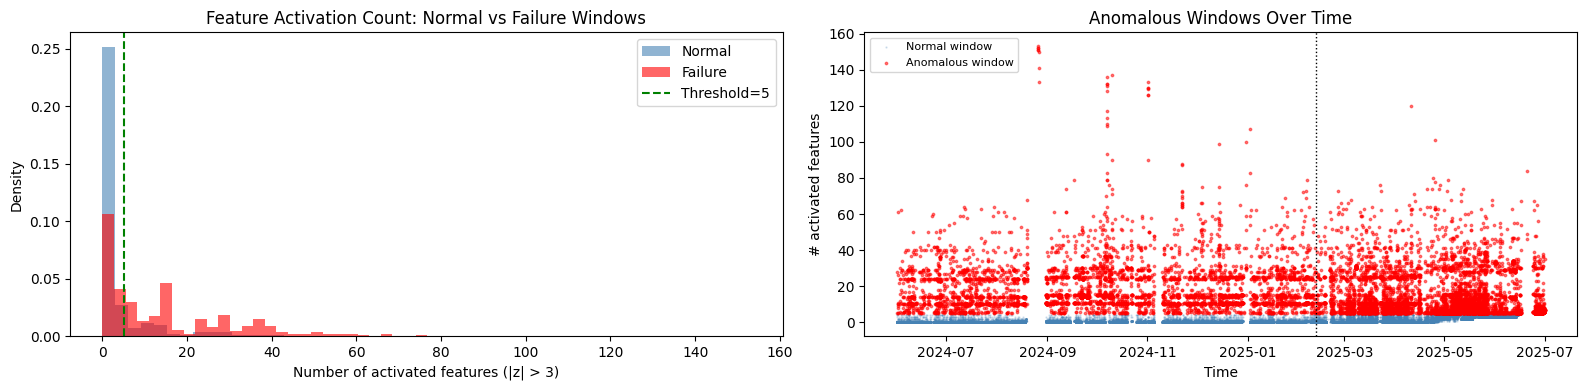

In [2]:
# Compute z-scores relative to train-normal distribution
train_normal = all_sup[(all_sup['split'] == 'train') & (all_sup['label'] == 0)]
feat_means = train_normal[feature_cols].mean()
feat_stds = train_normal[feature_cols].std()
feat_stds = feat_stds.replace(0, 1)  # avoid division by zero
del train_normal; gc.collect()

# Z-score all windows
Z_THRESH = 3.0  # a feature is "activated" if |z| > 3
zscores = (all_sup[feature_cols] - feat_means) / feat_stds
activations = (zscores.abs() > Z_THRESH).astype(int)  # binary: 1 = anomalous feature

# Count activated features per window
all_sup['n_activated'] = activations.sum(axis=1)

# A window is "anomalous" if >= 5 features are activated
MIN_ACTIVATED = 5
all_sup['is_anomalous'] = (all_sup['n_activated'] >= MIN_ACTIVATED).astype(int)

n_anom = all_sup['is_anomalous'].sum()
n_anom_fail = all_sup.loc[all_sup['is_anomalous'] == 1, 'label'].sum()
n_anom_normal = n_anom - n_anom_fail

print(f'Z-score threshold: |z| > {Z_THRESH}')
print(f'Min activated features: {MIN_ACTIVATED}')
print(f'\nAnomalous windows: {n_anom} / {len(all_sup)} ({100*n_anom/len(all_sup):.1f}%)')
print(f'  With failure label: {n_anom_fail} ({100*n_anom_fail/max(n_anom,1):.1f}%)')
print(f'  Without failure label: {n_anom_normal} ({100*n_anom_normal/max(n_anom,1):.1f}%)')
print(f'\nFor comparison:')
print(f'  Total failure windows: {all_sup["label"].sum()}')
print(f'  Failure windows that are anomalous: {n_anom_fail} ({100*n_anom_fail/max(all_sup["label"].sum(),1):.1f}%)')

# Distribution of n_activated
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

ax = axes[0]
ax.hist(all_sup.loc[all_sup['label']==0, 'n_activated'], bins=50, alpha=0.6, color='steelblue', label='Normal', density=True)
ax.hist(all_sup.loc[all_sup['label']==1, 'n_activated'], bins=50, alpha=0.6, color='red', label='Failure', density=True)
ax.axvline(MIN_ACTIVATED, color='green', linestyle='--', label=f'Threshold={MIN_ACTIVATED}')
ax.set_xlabel('Number of activated features (|z| > 3)')
ax.set_ylabel('Density')
ax.set_title('Feature Activation Count: Normal vs Failure Windows')
ax.legend()

ax = axes[1]
ax.scatter(all_sup.loc[all_sup['is_anomalous']==0, 'window_end'],
           all_sup.loc[all_sup['is_anomalous']==0, 'n_activated'],
           s=0.5, alpha=0.2, c='steelblue', label='Normal window')
ax.scatter(all_sup.loc[all_sup['is_anomalous']==1, 'window_end'],
           all_sup.loc[all_sup['is_anomalous']==1, 'n_activated'],
           s=3, alpha=0.5, c='red', label='Anomalous window')
ax.axvline(SPLIT_DATE, color='black', linestyle=':', linewidth=1)
ax.set_xlabel('Time')
ax.set_ylabel('# activated features')
ax.set_title('Anomalous Windows Over Time')
ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 2. Feature Activation Profiles

For each anomalous window, we have a binary vector: which of the 340 features are activated (|z| > 3)?

This is the "fingerprint" of each anomaly — which sensors are behaving unusually.

In [3]:
# Extract activation profiles for anomalous windows only
anom_mask = all_sup['is_anomalous'] == 1
anom_activations = activations.loc[anom_mask].reset_index(drop=True)
anom_meta = all_sup.loc[anom_mask, ['window_end', 'label', 'split', 'n_activated']].reset_index(drop=True)

print(f'Anomalous windows: {len(anom_activations)}')
print(f'Activation matrix shape: {anom_activations.shape}')

# Which features are most commonly activated?
feat_freq = anom_activations.sum().sort_values(ascending=False)
feat_freq_pct = (feat_freq / len(anom_activations) * 100).round(1)

print(f'\nTop 30 most frequently activated features:')
top30 = feat_freq.head(30)
for f, count in top30.items():
    pct = count / len(anom_activations) * 100
    sub = feat_subsystem[f]
    print(f'  {f:55s} {sub:10s} {count:5d} ({pct:5.1f}%)')

# Subsystem activation frequency
print(f'\nActivation frequency by subsystem:')
sub_activation = {}
for sub in ['Brake', 'Leveling', 'APU', 'Traction', 'Context', 'Asset']:
    sub_feats = [f for f in feature_cols if feat_subsystem[f] == sub]
    if sub_feats:
        mean_act = anom_activations[sub_feats].sum(axis=1).mean()
        any_act = (anom_activations[sub_feats].sum(axis=1) > 0).mean()
        sub_activation[sub] = {'n_features': len(sub_feats), 'mean_activated': mean_act, 'pct_windows_any': any_act * 100}
        print(f'  {sub:10s}: {len(sub_feats):3d} features | mean activated per window: {mean_act:.1f} | present in {any_act*100:.1f}% of anomalous windows')

# Never-activated features
never_activated = (feat_freq == 0).sum()
print(f'\nFeatures never activated: {never_activated} / {len(feature_cols)}')

Anomalous windows: 13125
Activation matrix shape: (13125, 340)

Top 30 most frequently activated features:
  MW4_LOAD_SIGNAL_min                                     Leveling    4104 ( 31.3%)
  MW3_BRAKE_CYLINDER_PRESSURE_BOGIE2_max                  Brake       3657 ( 27.9%)
  MW4_ENERGY_BRAKING_RESISTANCE_max                       Traction    3613 ( 27.5%)
  MW4_ENERGY_BRAKING_RESISTANCE_mean                      Traction    3597 ( 27.4%)
  MW2_BRAKE_CYLINDER_PRESSURE_BOGIE1_max                  Brake       3296 ( 25.1%)
  MW1_BRAKE_CYLINDER_PRESSURE_BOGIE1_max                  Brake       3071 ( 23.4%)
  MW4_BRAKE_CYLINDER_PRESSURE_BOGIE1_max                  Brake       3037 ( 23.1%)
  MW4_ENERGY_BRAKING_RESISTANCE_min                       Traction    2979 ( 22.7%)
  CW2_BRAKE_CYLINDER_PRESSURE_BOGIE1_min                  Brake       2685 ( 20.5%)
  MW2_BRAKE_CYLINDER_PRESSURE_BOGIE2_min                  Brake       2663 ( 20.3%)
  CW1_BRAKE_CYLINDER_PRESSURE_BOGIE2_min             

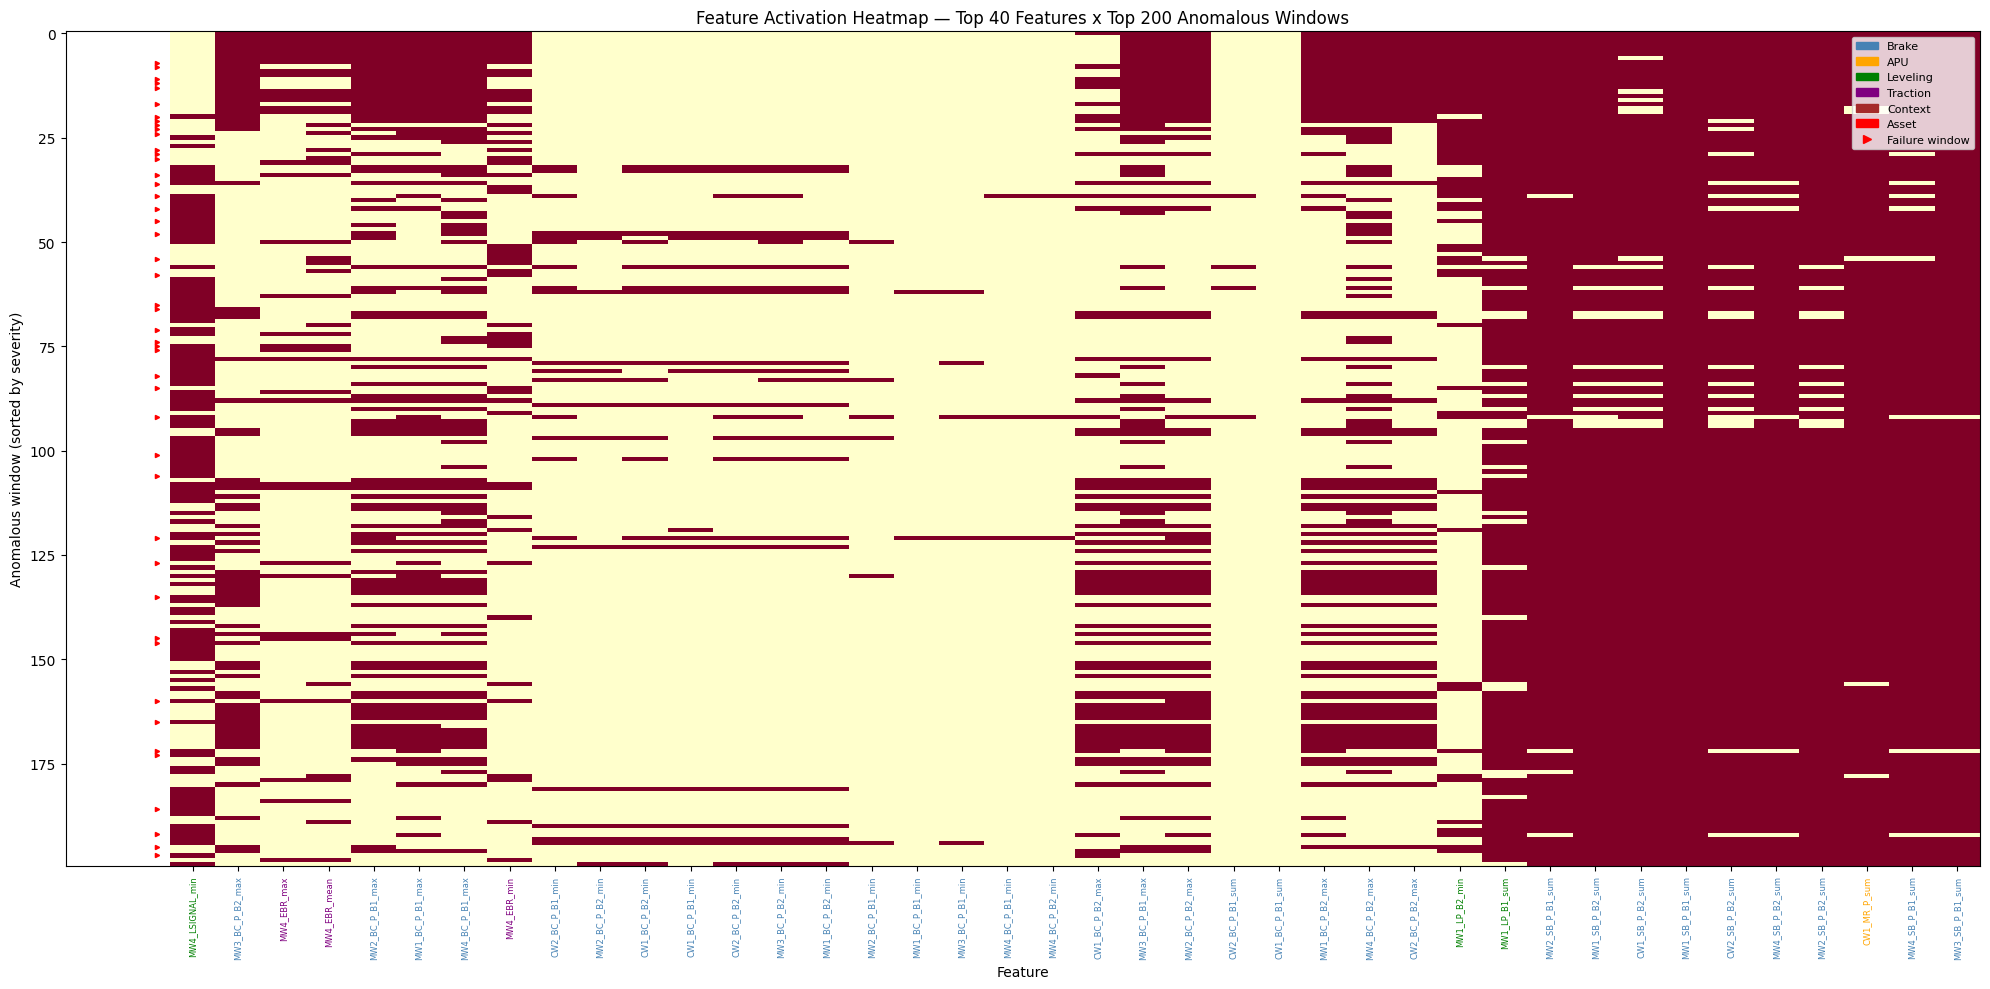

In [4]:
# Visualize: top 40 features activation heatmap (sample of anomalous windows)
top40_feats = feat_freq.head(40).index.tolist()
top40_subs = [feat_subsystem[f] for f in top40_feats]

# Sort anomalous windows by number of activations (most anomalous first)
sort_idx = anom_meta['n_activated'].argsort()[::-1]
sample_idx = sort_idx[:min(200, len(sort_idx))]  # top 200 most anomalous

heatmap_data = anom_activations.iloc[sample_idx][top40_feats].values

fig, ax = plt.subplots(figsize=(20, 10))
im = ax.imshow(heatmap_data, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_xlabel('Feature')
ax.set_ylabel('Anomalous window (sorted by severity)')
ax.set_title(f'Feature Activation Heatmap — Top 40 Features x Top {len(sample_idx)} Anomalous Windows')

# Color-code x-axis by subsystem
sub_colors = {'Brake': 'steelblue', 'APU': 'orange', 'Leveling': 'green',
              'Traction': 'purple', 'Context': 'brown', 'Asset': 'red'}
ax.set_xticks(range(len(top40_feats)))
short_labels = [f.replace('PRESSURE', 'P').replace('BOGIE', 'B').replace('BRAKE_CYLINDER', 'BC')
                .replace('SPRING_BRAKE', 'SB').replace('PROPORTIONAL_VALVE', 'PV')
                .replace('PNEUMATIC_BRAKING_FORCE', 'PBF').replace('LOAD_', 'L')
                .replace('MAIN_RESERVOIR', 'MR').replace('ENERGY_BRAKING_RESISTANCE', 'EBR')
                for f in top40_feats]
ax.set_xticklabels(short_labels, rotation=90, fontsize=6)
for i, sub in enumerate(top40_subs):
    ax.get_xticklabels()[i].set_color(sub_colors.get(sub, 'black'))

# Mark failure windows on y-axis
fail_rows = anom_meta.iloc[sample_idx]['label'].values
for i, is_fail in enumerate(fail_rows):
    if is_fail:
        ax.plot(-0.8, i, 'r>', markersize=3)

legend_patches = [Patch(color=c, label=s) for s, c in sub_colors.items()]
legend_patches.append(plt.Line2D([0], [0], marker='>', color='red', linestyle='', label='Failure window'))
ax.legend(handles=legend_patches, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## 3. Cluster Recurring Anomaly Patterns

Use hierarchical clustering on the binary activation profiles to find groups of anomalous windows that share similar sensor activation patterns.

**Distance metric:** Jaccard distance (appropriate for binary data — measures overlap of activated features).
**Linkage:** Ward's method.

Features activated in >= 131 windows: 176 / 340
Computing Jaccard distances...


Computing hierarchical clustering (Ward linkage)...


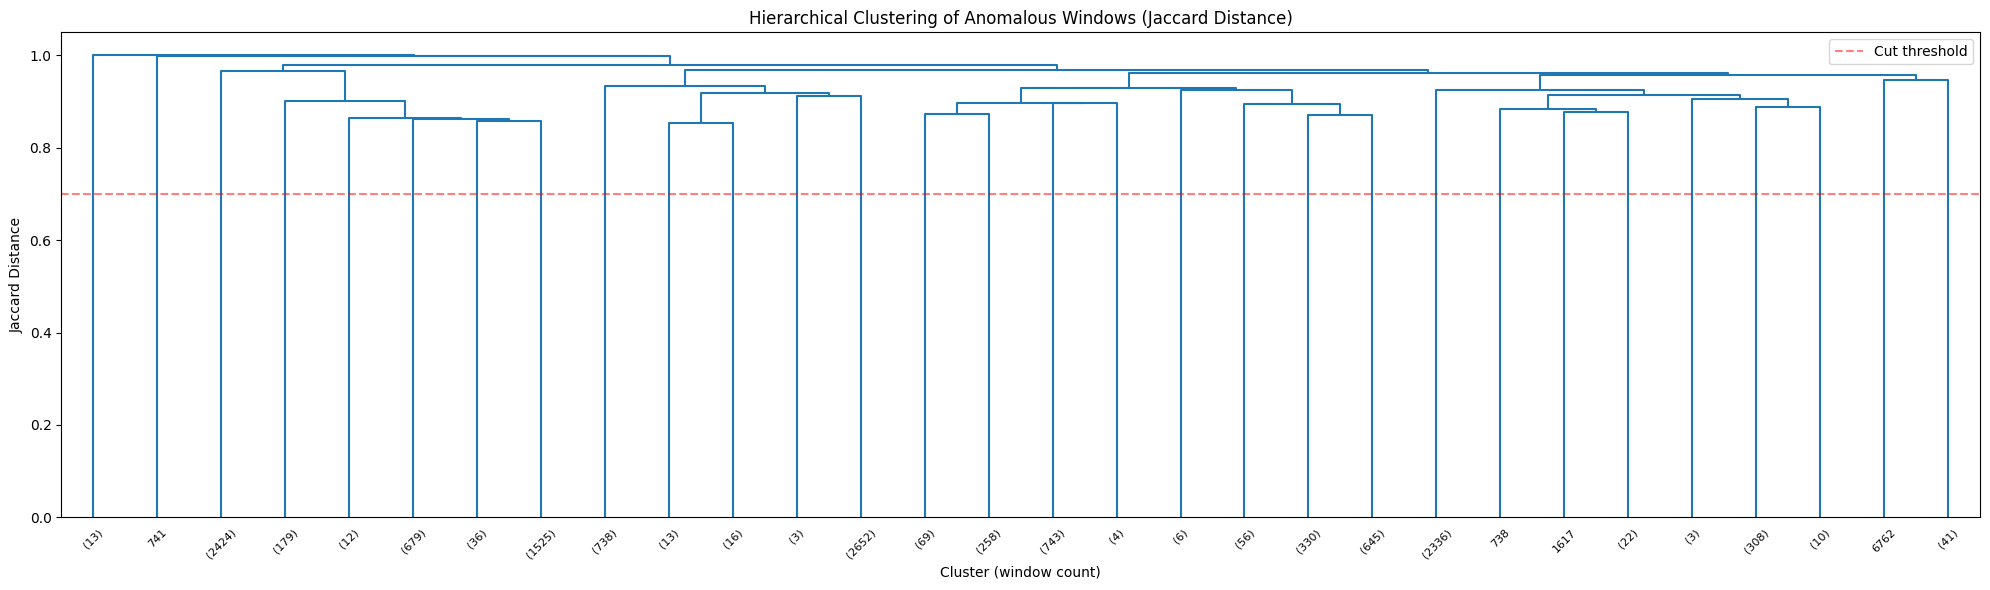

In [5]:
# Filter to features that are activated in at least 1% of anomalous windows
min_freq = max(int(len(anom_activations) * 0.01), 2)
active_feats = feat_freq[feat_freq >= min_freq].index.tolist()
print(f'Features activated in >= {min_freq} windows: {len(active_feats)} / {len(feature_cols)}')

# Compute Jaccard distance between anomalous windows
anom_binary = anom_activations[active_feats].values

print('Computing Jaccard distances...')
dist_matrix = pdist(anom_binary, metric='jaccard')

print('Computing hierarchical clustering (Ward linkage)...')
Z = linkage(dist_matrix, method='average')  # average linkage works better with Jaccard

# Plot dendrogram
fig, ax = plt.subplots(figsize=(20, 6))
dn = dendrogram(Z, ax=ax, truncate_mode='lastp', p=30, show_leaf_counts=True,
                leaf_font_size=8, color_threshold=0.7)
ax.set_xlabel('Cluster (window count)')
ax.set_ylabel('Jaccard Distance')
ax.set_title('Hierarchical Clustering of Anomalous Windows (Jaccard Distance)')
ax.axhline(0.7, color='red', linestyle='--', alpha=0.5, label='Cut threshold')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Try multiple cut thresholds and pick one that gives interpretable clusters
for t in [0.5, 0.6, 0.7, 0.8, 0.85, 0.9]:
    labels = fcluster(Z, t=t, criterion='distance')
    n_clusters = len(set(labels))
    sizes = pd.Series(labels).value_counts().sort_index()
    print(f't={t:.2f}: {n_clusters} clusters | sizes: {sizes.values[:10]}...')

# Select a cut threshold (adjust based on dendrogram)
CUT_THRESHOLD = 0.75
cluster_labels = fcluster(Z, t=CUT_THRESHOLD, criterion='distance')
anom_meta['cluster'] = cluster_labels

# Filter out tiny clusters (< 5 windows) — likely noise
cluster_sizes = anom_meta['cluster'].value_counts()
valid_clusters = cluster_sizes[cluster_sizes >= 5].index.tolist()
anom_meta['cluster_clean'] = anom_meta['cluster'].where(anom_meta['cluster'].isin(valid_clusters), other=-1)

n_valid = len(valid_clusters)
n_noise = (anom_meta['cluster_clean'] == -1).sum()
print(f'\nCut threshold: {CUT_THRESHOLD}')
print(f'Valid clusters (>= 5 windows): {n_valid}')
print(f'Noise windows (tiny clusters): {n_noise}')

t=0.50: 698 clusters | sizes: [13  3  2  1  1  1  1  2  1  1]...
t=0.60: 337 clusters | sizes: [13  3  2  2  1  1  2  1  2  5]...
t=0.70: 132 clusters | sizes: [  13    3    4    2    3    2    5    7   15 2383]...
t=0.80: 49 clusters | sizes: [  13    3    4    2 2415   55  124   12  677    1]...
t=0.85: 30 clusters | sizes: [  13 2424  179   12  679   36 1525  738   13   16]...
t=0.90: 18 clusters | sizes: [  13 2424  179 2252  738   29    3 2652 1074    6]...

Cut threshold: 0.75
Valid clusters (>= 5 windows): 54
Noise windows (tiny clusters): 55


In [7]:
# ── Cluster summary ──
print(f'\n{"="*90}')
print(f'{"Cluster":>8} {"Size":>6} {"Failure":>8} {"Fail%":>7} {"Train":>6} {"Test":>6} {"Mean Act":>9} {"Top Subsystem":>15}')
print(f'{"="*90}')

cluster_profiles = {}
for cl in sorted(valid_clusters):
    cl_mask = anom_meta['cluster_clean'] == cl
    cl_meta = anom_meta[cl_mask]
    cl_acts = anom_activations.loc[cl_mask.values, active_feats]
    
    size = len(cl_meta)
    n_fail = cl_meta['label'].sum()
    n_train = (cl_meta['split'] == 'train').sum()
    n_test = (cl_meta['split'] == 'test').sum()
    mean_act = cl_meta['n_activated'].mean()
    
    # Which subsystem dominates this cluster?
    sub_acts = {}
    for sub in ['Brake', 'Leveling', 'APU', 'Traction', 'Context', 'Asset']:
        sub_feats = [f for f in active_feats if feat_subsystem[f] == sub]
        if sub_feats:
            sub_acts[sub] = cl_acts[sub_feats].sum().sum() / max(size, 1)
    top_sub = max(sub_acts, key=sub_acts.get) if sub_acts else 'Unknown'
    
    # Store profile: mean activation per feature
    profile = cl_acts.mean()
    cluster_profiles[cl] = {
        'size': size, 'n_fail': n_fail, 'fail_pct': n_fail / size * 100,
        'n_train': n_train, 'n_test': n_test, 'mean_activated': mean_act,
        'top_subsystem': top_sub, 'profile': profile,
        'sub_activations': sub_acts,
    }
    
    print(f'{cl:>8} {size:>6} {n_fail:>8} {n_fail/size*100:>6.1f}% {n_train:>6} {n_test:>6} {mean_act:>9.1f} {top_sub:>15}')

print(f'{"="*90}')
print(f'{"TOTAL":>8} {sum(c["size"] for c in cluster_profiles.values()):>6} '
      f'{sum(c["n_fail"] for c in cluster_profiles.values()):>8}')


 Cluster   Size  Failure   Fail%  Train   Test  Mean Act   Top Subsystem
       1     13        0    0.0%     13      0       7.8           Brake
       7      5        1   20.0%      0      5       7.2           Brake
       8   2405       85    3.5%   1633    772      20.7           Brake
       9     12        1    8.3%      8      4       6.3        Leveling
      10     42        2    4.8%     18     24      11.9        Leveling
      12     86        8    9.3%     58     28      46.1           Brake
      13     38        1    2.6%     25     13      15.2             APU
      14     12       12  100.0%     12      0      52.3           Brake
      15    677      114   16.8%    383    294      26.5           Brake
      18     36        1    2.8%      1     35       8.8           Brake


      19   1525      107    7.0%    740    785      35.8           Brake
      20    738      134   18.2%    738      0      16.5           Brake
      21     13        0    0.0%      0     13       6.3           Brake
      22      8        2   25.0%      0      8       8.4        Leveling
      23      8        0    0.0%      0      8       6.8           Brake
      26   1960       64    3.3%   1332    628      10.9           Brake
      28     39        2    5.1%      0     39       6.3           Brake
      29      9        1   11.1%      0      9       5.8           Brake
      30     44        1    2.3%      0     44       6.6           Brake


      31     66        2    3.0%      8     58      15.0           Brake
      32     29        0    0.0%      0     29       7.3           Brake
      33     36        0    0.0%      0     36       7.9           Brake
      34     17        0    0.0%      0     17      19.2        Leveling
      35    449        5    1.1%      0    449       9.3           Brake
      36     69       27   39.1%     69      0      15.6           Brake
      37      8        0    0.0%      0      8       8.2        Leveling
      39    127        1    0.8%      2    125       7.3        Leveling
      40     17        0    0.0%      0     17      10.7        Leveling
      41     33        5   15.2%      0     33       8.7           Brake
      42     70        5    7.1%      0     70       8.8           Brake
      43     34        0    0.0%     32      2       6.4        Leveling
      44     10        0    0.0%      0     10       7.1        Leveling
      45      5        0    0.0%      0      5     

      46    694       63    9.1%      0    694       6.4        Leveling
      49      6        0    0.0%      5      1       5.7        Leveling
      52      8        0    0.0%      0      8       7.0        Leveling
      55      8        0    0.0%      5      3       7.9        Leveling
      57     18        0    0.0%      4     14       7.3        Leveling
      59      5        0    0.0%      0      5       9.8        Leveling
      60      7        0    0.0%      7      0      19.3           Brake
      61     52        0    0.0%      0     52       8.5           Brake
      62    271        2    0.7%    145    126       7.4        Leveling


      63    136        0    0.0%    109     27       8.6        Leveling
      64     27        0    0.0%     27      0       5.7        Leveling
      65     13        3   23.1%      0     13       7.3        Leveling
      66    265        4    1.5%    179     86      21.9        Leveling
      67    204        0    0.0%    204      0      14.3        Leveling
      68     12        1    8.3%      0     12       6.8           Brake
      69   2289       48    2.1%      0   2289       6.3        Traction
      70     34        2    5.9%      3     31       7.6        Traction
      72     22       20   90.9%     21      1      10.2        Leveling
      76    308       14    4.5%     61    247       7.0           Brake
      77     10        2   20.0%      3      7       8.4             APU
      78     41        8   19.5%     12     29      21.8           Brake
   TOTAL  13070      748


## 4. Link Clusters to Failure Events

For each cluster, find which failure events its windows are temporally close to. This reveals whether a cluster is a precursor to specific failure types.

In [8]:
import glob

# Load failure events from raw data
TS_COL = 'TIMESTAMP'
FAIL_COL = 'TRAIN_IS_IN_FAILURE'
FAIL_TYPE = 'TRAIN_FAILURE_TYPE'
MAINT_COL = 'TRAIN_IS_IN_MAINTENANCE'
HORIZON_S = 22326

all_files = sorted(
    glob.glob(os.path.join(ROOT, 'train', '**', '*.parquet'), recursive=True) +
    glob.glob(os.path.join(ROOT, 'test', '**', '*.parquet'), recursive=True)
)
chunks = []
for f in all_files:
    df = pd.read_parquet(f, columns=[TS_COL, FAIL_COL, FAIL_TYPE])
    chunks.append(df)
raw_meta = pd.concat(chunks, ignore_index=True)
del chunks; gc.collect()
raw_meta[TS_COL] = pd.to_datetime(raw_meta[TS_COL])
raw_meta.sort_values(TS_COL, inplace=True)

mask = raw_meta[FAIL_COL].astype(bool)
grp = (mask != mask.shift()).cumsum()
fail_events = (
    raw_meta[mask].groupby(grp[mask])
    .agg(start=(TS_COL, 'min'), end=(TS_COL, 'max'),
         event_type=(FAIL_TYPE, 'first'), n_rows=(TS_COL, 'count'))
    .reset_index(drop=True)
)
# Merge nearby events
merged = []
for _, row in fail_events.iterrows():
    if merged and row['event_type'] == merged[-1]['event_type'] and \
       (row['start'] - merged[-1]['end']).total_seconds() < 3600:
        merged[-1]['end'] = row['end']
        merged[-1]['n_rows'] += row['n_rows']
    else:
        merged.append(dict(row))
fail_events = pd.DataFrame(merged)
fail_events['duration_min'] = (fail_events['end'] - fail_events['start']).dt.total_seconds() / 60
fail_events['period'] = fail_events['start'].apply(lambda x: 'train' if x < SPLIT_DATE else 'test')
fail_events.index += 1
fail_events.index.name = 'event_id'
del raw_meta; gc.collect()

print(f'Failure events: {len(fail_events)}')

# For each anomalous window, find the nearest failure event
def find_nearest_failure(window_end, fail_events, horizon_s):
    """Find the nearest failure event within the prediction horizon."""
    horizon_end = window_end + pd.Timedelta(seconds=horizon_s)
    for idx, ev in fail_events.iterrows():
        # Window is a precursor if failure starts within horizon
        if ev['start'] >= window_end and ev['start'] <= horizon_end:
            return idx, ev['event_type'], 'precursor'
        # Window is during failure
        if ev['start'] <= window_end and ev['end'] >= window_end:
            return idx, ev['event_type'], 'during'
    return None, None, 'none'

# Map each anomalous window to failure events
print('Mapping anomalous windows to failure events...')
anom_meta['fail_event_id'] = None
anom_meta['fail_event_type'] = None
anom_meta['fail_relation'] = 'none'

for i, row in anom_meta.iterrows():
    eid, etype, rel = find_nearest_failure(row['window_end'], fail_events, HORIZON_S)
    anom_meta.at[i, 'fail_event_id'] = eid
    anom_meta.at[i, 'fail_event_type'] = etype
    anom_meta.at[i, 'fail_relation'] = rel

print(f'\nAnomalous window — failure relation:')
print(anom_meta['fail_relation'].value_counts().to_string())

Failure events: 21
Mapping anomalous windows to failure events...



Anomalous window — failure relation:
fail_relation
none         12371
during         410
precursor      344


In [9]:
# ── Cluster × Failure Event cross-tabulation ──
print('Cluster to Failure Event Mapping:')
print('='*100)

for cl in sorted(valid_clusters):
    cl_data = anom_meta[anom_meta['cluster_clean'] == cl]
    cp = cluster_profiles[cl]
    
    print(f'\n--- Cluster {cl} ({cp["size"]} windows, {cp["fail_pct"]:.1f}% failure, dominant: {cp["top_subsystem"]}) ---')
    
    # Relation breakdown
    rel_counts = cl_data['fail_relation'].value_counts()
    for rel, count in rel_counts.items():
        print(f'  {rel}: {count} windows')
    
    # Which failure types?
    linked = cl_data[cl_data['fail_relation'] != 'none']
    if len(linked) > 0:
        type_counts = linked['fail_event_type'].value_counts()
        for ft, count in type_counts.items():
            event_ids = linked.loc[linked['fail_event_type'] == ft, 'fail_event_id'].unique()
            print(f'  → {ft}: {count} windows across events {sorted([int(e) for e in event_ids if e is not None])}')
    
    # Top 5 activated features in this cluster
    profile = cp['profile']
    top5 = profile.nlargest(5)
    print(f'  Top features: ', end='')
    print(', '.join([f'{f.split("_")[-1]}({feat_subsystem[f][0]})' if len(f) > 30 
                     else f'{f}({feat_subsystem[f][0]})' for f, v in top5.items()]))

Cluster to Failure Event Mapping:

--- Cluster 1 (13 windows, 0.0% failure, dominant: Brake) ---
  none: 13 windows
  Top features: MW4_LOAD_SIGNAL_min(L), max(B), max(T), mean(T), max(B)

--- Cluster 7 (5 windows, 20.0% failure, dominant: Brake) ---
  none: 4 windows
  precursor: 1 windows
  → Brake System Failure: 1 windows across events [14]
  Top features: min(B), sum(B), sum(B), sum(B), min(B)

--- Cluster 8 (2405 windows, 3.5% failure, dominant: Brake) ---
  none: 2320 windows
  during: 47 windows
  precursor: 38 windows
  → Brake System Failure: 61 windows across events [1, 4, 6, 7, 9, 10, 13, 14, 15, 20]
  → Compressor Module Failure: 18 windows across events [12, 17, 19, 21]
  → Leveling System Failure: 6 windows across events [18]
  Top features: min(B), min(B), min(B), min(B), min(B)

--- Cluster 9 (12 windows, 8.3% failure, dominant: Leveling) ---
  none: 11 windows
  during: 1 windows
  → Brake System Failure: 1 windows across events [6]
  Top features: CW1_LOAD_SIGNAL_sum

## 5. Map Clusters to Subsystems

Visualize how each cluster's activated features map to subsystems. This reveals whether clusters align with domain subsystems or span across them.



In [10]:
# Subsystem activation breakdown per cluster
subsystems = ['Brake', 'Leveling', 'APU', 'Traction', 'Context', 'Asset']
sub_colors = {'Brake': 'steelblue', 'APU': 'orange', 'Leveling': 'green',
              'Traction': 'purple', 'Context': 'brown', 'Asset': 'red'}

n_cl = len(valid_clusters)
fig, axes = plt.subplots(1, n_cl, figsize=(5 * n_cl, 5), sharey=True)
if n_cl == 1:
    axes = [axes]

for ax, cl in zip(axes, sorted(valid_clusters)):
    cp = cluster_profiles[cl]
    subs = cp['sub_activations']
    
    bars = ax.barh(list(subs.keys()), list(subs.values()),
                   color=[sub_colors.get(s, 'gray') for s in subs.keys()])
    ax.set_xlabel('Mean activated features per window')
    ax.set_title(f'Cluster {cl}\n{cp["size"]} windows, {cp["fail_pct"]:.0f}% failure\n'
                 f'Dominant: {cp["top_subsystem"]}', fontsize=10)

plt.suptitle('Subsystem Activation Breakdown per Cluster', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



In [11]:
# ── Cluster activation profile comparison (heatmap) ──
# Show which features define each cluster
profile_matrix = pd.DataFrame({f'C{cl}': cluster_profiles[cl]['profile'] for cl in sorted(valid_clusters)})

# Keep only features activated in > 20% of windows in at least one cluster
significant = profile_matrix.max(axis=1) > 0.2
profile_sig = profile_matrix[significant].copy()

# Sort by subsystem
profile_sig['subsystem'] = [feat_subsystem[f] for f in profile_sig.index]
sub_order = ['Brake', 'Leveling', 'APU', 'Traction', 'Context', 'Asset']
profile_sig['sub_rank'] = profile_sig['subsystem'].map({s: i for i, s in enumerate(sub_order)})
profile_sig = profile_sig.sort_values(['sub_rank', profile_sig.columns[0]], ascending=[True, False])
subsystem_labels = profile_sig['subsystem'].values
profile_sig = profile_sig.drop(columns=['subsystem', 'sub_rank'])

fig, ax = plt.subplots(figsize=(max(8, n_cl * 2), max(10, len(profile_sig) * 0.25)))
im = ax.imshow(profile_sig.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(profile_sig.columns)))
ax.set_xticklabels(profile_sig.columns, fontsize=10)
ax.set_yticks(range(len(profile_sig)))
short_names = [f.replace('PRESSURE', 'P').replace('BOGIE', 'B').replace('BRAKE_CYLINDER', 'BC')
               .replace('SPRING_BRAKE', 'SB').replace('PROPORTIONAL_VALVE', 'PV')
               .replace('PNEUMATIC_BRAKING_FORCE', 'PBF').replace('LOAD_', 'L')
               .replace('MAIN_RESERVOIR', 'MR').replace('ENERGY_BRAKING_RESISTANCE', 'EBR')
               for f in profile_sig.index]
ax.set_yticklabels(short_names, fontsize=6)

# Color y-labels by subsystem
for i, sub in enumerate(subsystem_labels):
    ax.get_yticklabels()[i].set_color(sub_colors.get(sub, 'black'))

plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label='Activation frequency')
ax.set_title('Cluster Activation Profiles — Features Activated in >20% of Cluster Windows', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Construct Subsystem-Aware Feature Groups

Based on the cluster analysis, define feature groups that can be used as subsystem-aware subdatasets.

Each group contains the sensors that co-activate during a specific anomaly pattern.

In [12]:
# For each cluster, identify the core features (activated in >30% of windows)
CORE_THRESHOLD = 0.30

feature_groups = {}
skipped_clusters = []
print('Subsystem-Aware Feature Groups (from anomaly clusters):')
print('='*90)

for cl in sorted(valid_clusters):
    cp = cluster_profiles[cl]
    profile = cp['profile']
    core_feats = profile[profile >= CORE_THRESHOLD].sort_values(ascending=False)
    
    # Map core features back to raw sensor names
    core_sensors = set()
    for f in core_feats.index:
        for suffix in ['_min', '_max', '_mean', '_sum', '_active_s', '_flips']:
            if f.endswith(suffix):
                core_sensors.add(f[:-len(suffix)])
                break
    
    if not core_sensors:
        skipped_clusters.append(cl)
        print(f'\n  Cluster {cl}: SKIPPED — no features above {CORE_THRESHOLD:.0%} threshold')
        continue
    
    # All features derived from these sensors
    group_features = [f for f in feature_cols if any(f.startswith(s) for s in core_sensors)]
    
    # Subsystem composition
    sensor_subs = {}
    for s in core_sensors:
        sub = get_subsystem(s + '_mean')
        sensor_subs.setdefault(sub, []).append(s)
    
    if not sensor_subs:
        skipped_clusters.append(cl)
        print(f'\n  Cluster {cl}: SKIPPED — no subsystem mapping')
        continue
    
    # Name the group based on composition
    dominant = max(sensor_subs, key=lambda k: len(sensor_subs[k]))
    if len(sensor_subs) == 1:
        group_name = f'C{cl}_{dominant}'
    else:
        group_name = f'C{cl}_Cross({"_".join(sorted(sensor_subs.keys()))})'
    
    feature_groups[group_name] = {
        'cluster_id': cl,
        'sensors': sorted(core_sensors),
        'features': sorted(group_features),
        'n_sensors': len(core_sensors),
        'n_features': len(group_features),
        'subsystem_composition': {k: sorted(v) for k, v in sensor_subs.items()},
        'cluster_size': cp['size'],
        'failure_pct': cp['fail_pct'],
        'linked_failure_types': list(anom_meta.loc[
            (anom_meta['cluster_clean'] == cl) & (anom_meta['fail_relation'] != 'none'),
            'fail_event_type'
        ].dropna().unique()),
    }
    
    print(f'\n{group_name}:')
    print(f'  From cluster {cl}: {cp["size"]} windows, {cp["fail_pct"]:.1f}% failure')
    print(f'  Sensors: {len(core_sensors)} → Features: {len(group_features)}')
    print(f'  Subsystem composition:')
    for sub, sensors in sorted(sensor_subs.items()):
        print(f'    {sub}: {len(sensors)} sensors — {sensors[:5]}{"..." if len(sensors)>5 else ""}')
    if feature_groups[group_name]['linked_failure_types']:
        print(f'  Linked failure types: {feature_groups[group_name]["linked_failure_types"]}')
    else:
        print(f'  Linked failure types: NONE (operational anomaly only)')

print(f'\n{"="*90}')
print(f'Total feature groups: {len(feature_groups)}')
if skipped_clusters:
    print(f'Skipped clusters (no core features): {skipped_clusters}')

Subsystem-Aware Feature Groups (from anomaly clusters):

  Cluster 1: SKIPPED — no features above 30% threshold

C7_Brake:
  From cluster 7: 5 windows, 20.0% failure
  Sensors: 5 → Features: 20
  Subsystem composition:
    Brake: 5 sensors — ['MW1_BRAKE_CYLINDER_PRESSURE_BOGIE1', 'CW1_BRAKE_CYLINDER_PRESSURE_BOGIE1', 'CW1_BRAKE_CYLINDER_PRESSURE_BOGIE2', 'CW2_BRAKE_CYLINDER_PRESSURE_BOGIE1', 'MW2_BRAKE_CYLINDER_PRESSURE_BOGIE1']
  Linked failure types: ['Brake System Failure']

C8_Cross(Brake_Leveling):
  From cluster 8: 2405 windows, 3.5% failure
  Sensors: 13 → Features: 52
  Subsystem composition:
    Brake: 12 sensors — ['MW1_BRAKE_CYLINDER_PRESSURE_BOGIE1', 'MW3_BRAKE_CYLINDER_PRESSURE_BOGIE1', 'CW1_BRAKE_CYLINDER_PRESSURE_BOGIE1', 'MW4_BRAKE_CYLINDER_PRESSURE_BOGIE1', 'MW3_BRAKE_CYLINDER_PRESSURE_BOGIE2']...
    Leveling: 1 sensors — ['MW4_LOAD_SIGNAL']
  Linked failure types: ['Brake System Failure', 'Compressor Module Failure', 'Leveling System Failure']

C9_Cross(APU_Leveling)

In [13]:
# ── Save feature groups for expert verification ──
# Clean for JSON serialization
groups_for_json = {}
for name, info in feature_groups.items():
    groups_for_json[name] = {
        'cluster_id': int(info['cluster_id']),
        'sensors': info['sensors'],
        'n_sensors': info['n_sensors'],
        'features': info['features'],
        'n_features': info['n_features'],
        'subsystem_composition': info['subsystem_composition'],
        'cluster_size': int(info['cluster_size']),
        'failure_pct': round(info['failure_pct'], 1),
        'linked_failure_types': info['linked_failure_types'],
    }

out_path = os.path.join(OUT_DIR, 'feature_groups.json')
with open(out_path, 'w') as f:
    json.dump(groups_for_json, f, indent=2)
print(f'Saved feature groups to {out_path}')

Saved feature groups to C:\Users\Emırhan\Desktop\MASTER THESIS\Kurtulus-thesis\outputs\feature_groups.json


## 7. Summary for Expert Verification

Summary table and chain diagram for the meeting with domain experts.

In [14]:
# ── Meeting-ready summary ──
print('='*90)
print('ANOMALY PATTERN DISCOVERY — SUMMARY FOR EXPERT VERIFICATION')
print('='*90)

print(f'\nDataset: {len(all_sup):,} windows (Jun 2024 – Jun 2025)')
print(f'Anomalous windows (|z|>{Z_THRESH}, >={MIN_ACTIVATED} features): {n_anom}')
print(f'Clustering: Jaccard distance + average linkage, cut={CUT_THRESHOLD}')
print(f'Valid clusters (>=5 windows): {len(valid_clusters)}')

print(f'\n--- Feature → Event → Failure → Dataset Chain ---')
print(f'')
for name, info in feature_groups.items():
    fail_types = info['linked_failure_types']
    fail_str = ', '.join(fail_types) if fail_types else 'None (operational)'
    subs = list(info['subsystem_composition'].keys())
    print(f'  {name}:')
    print(f'    Features:  {info["n_sensors"]} sensors → {info["n_features"]} features')
    print(f'    Subsystems: {subs}')
    print(f'    Events:    {info["cluster_size"]} anomalous windows ({info["failure_pct"]:.0f}% with failure label)')
    print(f'    Failures:  {fail_str}')
    print(f'    → Dataset: {info["n_features"]} features from {subs}')
    print()

print('--- Baseline Comparison ---')
print(f'  FULL Baseline: {len(feature_cols)} features (all sensors, flat)')
for name, info in feature_groups.items():
    print(f'  {name}: {info["n_features"]} features ({info["n_sensors"]} sensors)')

print(f'\n--- Questions for Domain Experts ---')
print('  1. Do these sensor groupings make operational sense?')
print('  2. Are there known failure modes that align with these patterns?')
print('  3. Should any clusters be merged or split?')
print('  4. Are the "operational-only" clusters (no failure link) expected behavior?')

ANOMALY PATTERN DISCOVERY — SUMMARY FOR EXPERT VERIFICATION

Dataset: 64,522 windows (Jun 2024 – Jun 2025)
Anomalous windows (|z|>3.0, >=5 features): 13125
Clustering: Jaccard distance + average linkage, cut=0.75
Valid clusters (>=5 windows): 54

--- Feature → Event → Failure → Dataset Chain ---

  C7_Brake:
    Features:  5 sensors → 20 features
    Subsystems: ['Brake']
    Events:    5 anomalous windows (20% with failure label)
    Failures:  Brake System Failure
    → Dataset: 20 features from ['Brake']

  C8_Cross(Brake_Leveling):
    Features:  13 sensors → 52 features
    Subsystems: ['Brake', 'Leveling']
    Events:    2405 anomalous windows (4% with failure label)
    Failures:  Brake System Failure, Compressor Module Failure, Leveling System Failure
    → Dataset: 52 features from ['Brake', 'Leveling']

  C9_Cross(APU_Leveling):
    Features:  5 sensors → 16 features
    Subsystems: ['APU', 'Leveling']
    Events:    12 anomalous windows (8% with failure label)
    Failures: 

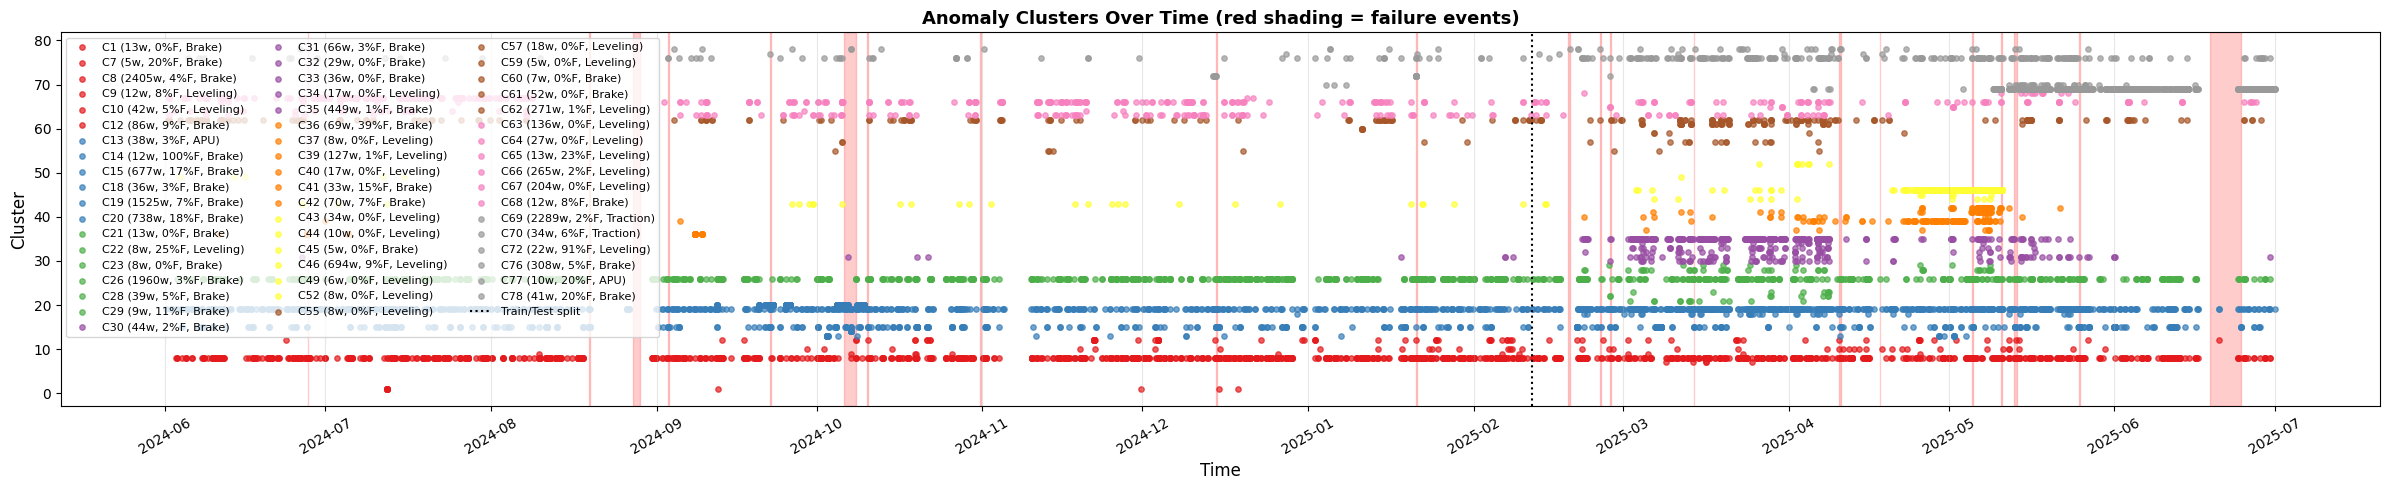

Saved anomaly_clusters_timeline.png


In [15]:
# ── Timeline: show where each cluster's windows appear ──
fig, ax = plt.subplots(figsize=(24, 5))

cluster_colors = plt.cm.Set1(np.linspace(0, 1, max(len(valid_clusters), 3)))
cl_color_map = {cl: cluster_colors[i] for i, cl in enumerate(sorted(valid_clusters))}

# Plot failure events
for _, ev in fail_events.iterrows():
    ax.axvspan(ev['start'], ev['end'], alpha=0.2, color='red')

# Plot cluster windows
for cl in sorted(valid_clusters):
    cl_data = anom_meta[anom_meta['cluster_clean'] == cl]
    ax.scatter(cl_data['window_end'], [cl] * len(cl_data),
              s=15, c=[cl_color_map[cl]], alpha=0.7,
              label=f'C{cl} ({cluster_profiles[cl]["size"]}w, {cluster_profiles[cl]["fail_pct"]:.0f}%F, {cluster_profiles[cl]["top_subsystem"]})')

ax.axvline(SPLIT_DATE, color='black', linestyle=':', linewidth=1.5, label='Train/Test split')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title('Anomaly Clusters Over Time (red shading = failure events)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=8, ncol=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'anomaly_clusters_timeline.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved anomaly_clusters_timeline.png')